UNSCALED FEATURE
θ* (empirical minimizer): [2.99954023 2.21509616]
θ_T after GD: [3.00288818 0.01708676]
Distance ||θ_T - θ*||: 2.1980119474694213
Iterations to converge: None


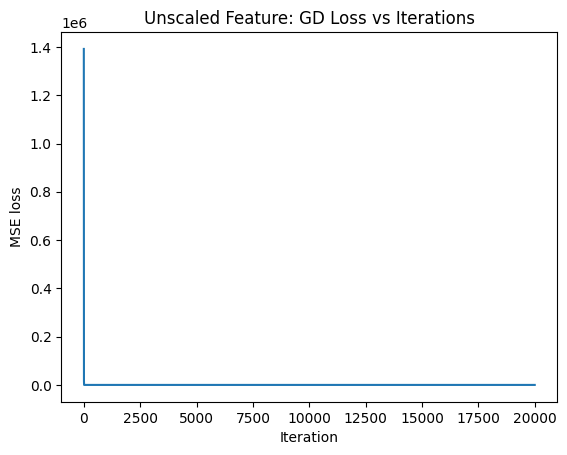

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------ Dataset ------------------
num_samples = 100
np.random.seed(42)

x = np.random.uniform(0, 1000, num_samples).reshape(-1, 1)
f_x = 3 * x + 2
eps = np.random.randn(num_samples).reshape(-1, 1)
y = f_x + eps

def add_bias(x):
    return np.hstack([x, np.ones((x.shape[0], 1))])

def mse_loss(X, y, theta):
    y_pred = X @ theta
    return np.mean((y_pred - y) ** 2) / 2

def theta_star_normal_eq(X, y):
    # empirical least-squares minimizer θ*
    XtX = X.T @ X
    Xty = X.T @ y
    return np.linalg.inv(XtX) @ Xty   # shape (2,1)

def full_batch_gd(X, y, theta_star, lr, eps=1e-3, max_iters=20000):
    n, d = X.shape
    theta = np.zeros((d, 1))
    losses = []

    for t in range(max_iters):
        losses.append(mse_loss(X, y, theta))

        grad = (X.T @ (X @ theta - y)) / n
        theta = theta - lr * grad

        # convergence check: ||θ_t - θ*|| < ε
        if np.linalg.norm(theta - theta_star) < eps:
            return theta, np.array(losses), t + 1

    # if we never hit the ε-neighbourhood
    return theta, np.array(losses), None

# ---------- (a) Unscaled feature ----------
X = add_bias(x)
theta_star = theta_star_normal_eq(X, y)

theta_unscaled, losses_unscaled, iters_unscaled = full_batch_gd(
    X, y, theta_star,
    lr=1e-6,          # small LR needed to stay stable with large feature scale
    eps=1e-4,
    max_iters=20000
)

print("UNSCALED FEATURE")
print("θ* (empirical minimizer):", theta_star.ravel())
print("θ_T after GD:", theta_unscaled.ravel())
print("Distance ||θ_T - θ*||:", np.linalg.norm(theta_unscaled - theta_star))
print("Iterations to converge:", iters_unscaled)   # will be None here

# Plot loss vs iterations
plt.figure()
plt.plot(np.arange(len(losses_unscaled)), losses_unscaled)
plt.xlabel("Iteration")
plt.ylabel("MSE loss")
plt.title("Unscaled Feature: GD Loss vs Iterations")
plt.show()



SCALED FEATURE (z-score)
θ* (empirical minimizer, scaled space): [ 887.85858784 1412.54114977]
θ_T after GD: [ 887.85805656 1412.54030453]
Distance ||θ_T - θ*||: 0.0009983481011901464
Iterations to converge: 136


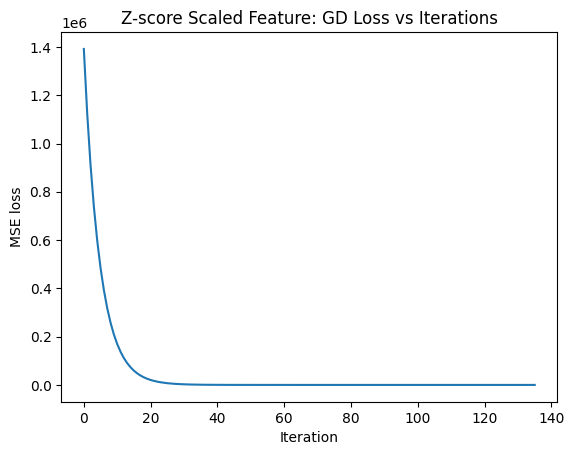

In [2]:
# ---------- (b) Z-score normalized feature ----------
x_mean = x.mean()
x_std = x.std()
x_scaled = (x - x_mean) / x_std        # z-score

Xs = add_bias(x_scaled)
theta_star_scaled = theta_star_normal_eq(Xs, y)

theta_scaled, losses_scaled, iters_scaled = full_batch_gd(
    Xs, y, theta_star_scaled,
    lr=0.1,           # much larger LR now possible
    eps=1e-3,
    max_iters=20000
)

print("\nSCALED FEATURE (z-score)")
print("θ* (empirical minimizer, scaled space):", theta_star_scaled.ravel())
print("θ_T after GD:", theta_scaled.ravel())
print("Distance ||θ_T - θ*||:", np.linalg.norm(theta_scaled - theta_star_scaled))
print("Iterations to converge:", iters_scaled)

plt.figure()
plt.plot(np.arange(len(losses_scaled)), losses_scaled)
plt.xlabel("Iteration")
plt.ylabel("MSE loss")
plt.title("Z-score Scaled Feature: GD Loss vs Iterations")
plt.show()
